In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import OrderedDict

In [195]:
model = "gpt2-xl"
template = "0_shot"
datasets = {
    # "glue/cola": "CoLA",
    "glue/sst2": "SST-2",

    # "glue/mrpc": "MRPC",
    # # "glue/stsb": "STS-B
    # # "glue/qqp": "QQP",

    # "glue/mnli": "MNLI",
    # "glue/qnli": "QNLI",
    # "glue/rte": "RTE",
    # # "glue/wnli": "WNLI",
}
num_samples = [50, 200, 800, 2000, 3800]
methods = OrderedDict([
    # Baseline:
    ("baseline", {"label": "No adaptation", "color": "black", "linestyle": "--"}),

    # Fine-tuning:
    ("embeddings_ft_map=identity_affine_alpha=matrix_bias=True_loss=log-loss", {"label": "Fine-tunning", "color": "tab:orange", "linestyle": "--", "marker": "*", "markersize": 7}),
    
    # Affine:
    # ("logits_ft_map=identity_affine_alpha=matrix_bias=True_loss=log-loss", {"label": "Affine\nMatrix", "color": "tab:red"}),
    # ("logits_ft_map=identity_affine_alpha=vector_bias=True_loss=log-loss", {"label": "Affine\nVector", "color": "tab:blue"}),
    # ("logits_ft_map=identity_affine_alpha=scalar_bias=True_loss=log-loss", {"label": "Affine\nScalar", "color": "tab:cyan"}),
    # ("logits_affine_alpha=scalar_bias=True_loss=log-loss", {"label": "Temperature\nScaling", "color": "tab:olive"}),
    # ("logits_ft_map=identity_affine_alpha=none_bias=True_loss=log-loss", {"label": "Bias\nOnly", "color": "tab:green"}),
    
    # Feature map + affine:
    ("embeddings_ft_map=quadratic_affine_alpha=matrix_bias=True_loss=log-loss", {"label": "Feature map\n+ Affine Matrix\n(embeddings)", "color": "tab:purple", "linestyle": "--", "marker": "*", "markersize": 7}),
    # ("logits_ft_map=quadratic_affine_alpha=matrix_bias=True_loss=log-loss", {"label": "Feature map\n+ Affine Matrix\n(logits)", "color": "tab:purple"}),

    # Mahalanobis:
    ("embeddings_ft_map=identity_mahalanobis", {"label": "Mahalanobis\n(Embeddings)", "color": "tab:brown", "linestyle": "--", "marker": "*", "markersize": 7}),
    # ("logits_ft_map=identity_mahalanobis", {"label": "Mahalanobis\n(logits)", "color": "tab:brown"}),

    # QDA:
    ("embeddings_ft_map=identity_qda", {"label": "QDA\n(embeddings)", "color": "tab:pink", "linestyle": "--", "marker": "*", "markersize": 7}),
    # ("logits_ft_map=identity_qda", {"label": "QDA\n(logits)", "color": "tab:pink", "linestyle": "--"}),

    # LDA:    
    ("embeddings_ft_map=identity_lda", {"label": "LDA\n(embeddings)", "color": "tab:gray", "linestyle": "--", "marker": "*", "markersize": 7}),
    # ("logits_ft_map=identity_lda", {"label": "LDA\n(logits)", "color": "tab:gray", "linestyle": "--"}),
    
])

metrics = OrderedDict([
    # ("cross_entropy", "Cross Entropy"),
    ("norm_cross_entropy", {"name": "Normalized\nCross Entropy", "ylims": (0.0, 2.0)}),
    # ("norm_cross_entropy", {"name": "Normalized\nCross Entropy", "ylims": None}),
    ("error_rate", {"name": "Error Rate", "ylims": None}),
])

random_state = 27348

In [196]:
from scipy.special import log_softmax

def compute_metric(logits, labels, metric="error_rate", bootstrap=False, num_samples=1000, random_state=0):

    def _compute_metric(logits, labels, metric="error_rate"):
        if metric == "error_rate":
            return np.mean(np.argmax(logits, axis=1) != labels)
        elif metric == "cross_entropy":
            logprobs = log_softmax(logits, axis=1)
            return -np.mean(logprobs[np.arange(len(logits)), labels])
        elif metric == "norm_cross_entropy":
            counts = np.bincount(labels, minlength=logits.shape[1])
            dummy_logprobs = np.log(counts / np.sum(counts))
            logprobs = log_softmax(logits, axis=1)
            return np.mean(logprobs[np.arange(len(logits)), labels]) / np.mean(dummy_logprobs[labels])
        else:
            raise ValueError("Invalid metric: %s" % metric)

    if bootstrap:
        rs = np.random.RandomState(random_state)
        metrics = []
        for _ in range(num_samples):
            idx = rs.randint(0, len(logits), len(logits))
            metrics.append(_compute_metric(logits[idx], labels[idx], metric=metric))
    else:
        metrics = [_compute_metric(logits, labels, metric=metric)]

    return metrics

        

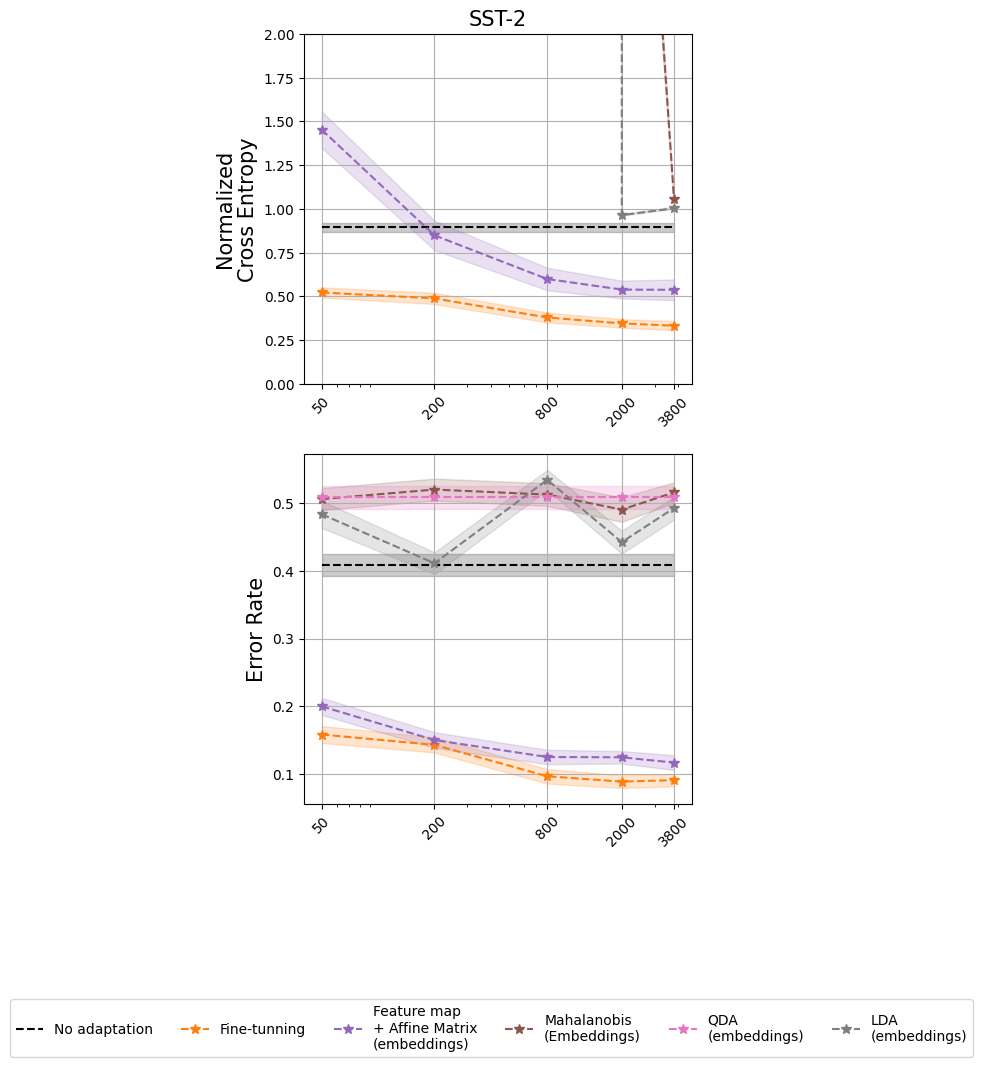

In [197]:
def plot_samples_vs_metric(
    model,
    template,
    datasets,
    num_samples,
    methods,
    metrics,
):
    fig, ax = plt.subplots(len(metrics), len(datasets), figsize=(len(datasets) * 5, len(metrics) * 5))
    if len(metrics) == 1 and len(datasets) == 1:
        ax = np.array([[ax]])
    elif len(metrics) == 1:
        ax = ax.reshape(-1, 1)
    elif len(datasets) == 1:
        ax = ax.reshape(1, -1)
    for i, dataset in enumerate(datasets):
        for j, metric in enumerate(metrics):
            for method in methods:
                if method == "baseline":
                    logits = np.load(f"../results/run_dataset_on_model/{model}/{dataset}/validation/{template}/logits.npy")
                    labels = np.load(f"../results/run_dataset_on_model/{model}/{dataset}/validation/{template}/labels.npy")
                    metric_values = compute_metric(logits, labels, metric=metric, bootstrap=True, num_samples=100, random_state=random_state)
                    means = np.ones(len(num_samples)) * np.mean(metric_values)
                    stds = np.ones(len(num_samples)) * np.std(metric_values)
                else:
                    means, stds = [], []
                    for n in num_samples:
                        try:
                            logits = np.load(f"../results/calibrate_features/{model}/{dataset}/{template}--{n}/{method}/calibrated_posteriors.npy")
                            labels = np.load(f"../results/run_dataset_on_model/{model}/{dataset}/validation/{template}/labels.npy")
                            metric_values = compute_metric(logits, labels, metric=metric, bootstrap=True, num_samples=100, random_state=random_state)
                        except FileNotFoundError:
                            metric_values = np.nan
                        means.append(np.mean(metric_values))
                        stds.append(np.std(metric_values))
                    means = np.array(means)
                    stds = np.array(stds)
                ax[i,j].plot(num_samples, means, **methods[method])
                ax[i,j].fill_between(num_samples, means - stds, means + stds, alpha=0.2, color=methods[method]["color"])
            ax[i,j].set_xscale("log")
            ax[i,j].set_xticks(num_samples)
            ax[i,j].set_xticklabels(num_samples, fontsize=10, rotation=45)
            ax[i,j].grid()
            ax[i,j].set_ylim(metrics[metric]["ylims"])

            if j == 0:
                ax[i,j].set_title(datasets[dataset], fontsize=15)
            if i == 0:
                ax[i,j].set_ylabel(metrics[metric]["name"], fontsize=15)

            

    # Unique legend showing under all subplots
    handles, labels = ax[0,0].get_legend_handles_labels()
    unique_labels = [methods[method]["label"] for method in methods if methods[method]["label"] in set(labels)]
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    fig.legend(unique_handles, unique_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(unique_labels), fontsize=10)
    return fig, ax

_ = plot_samples_vs_metric(model, template, datasets, num_samples, methods, metrics)


In [198]:
# Motivación: Mahalanobis funciona bien y esto es una buena aplicación. 
# podés reducir el problema a una LR y te queda un problema convexo.
